# 🏠 PRACTICE 4: Predicting House Prices with PyTorch MLP  
**Dataset:** California Housing Dataset (from `sklearn.datasets`)

---

## 🎯 Problem Statement

The goal of this project is to predict **median house values** in California districts based on several input features such as:

- Median income  
- Housing age  
- Average number of rooms  
- Population  

This is a **supervised regression problem**, where the model learns a mapping:

$$
y = f(X)
$$

Where:
- \( X \): input features  
- \( y \): house price  

---

## 📊 Objective

- Build a **Multilayer Perceptron (MLP)** using **PyTorch**
- Train the model on housing data
- Evaluate performance using regression metrics such as:

### Mean Squared Error (MSE)

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- Compare predicted vs actual values


## 1. Import Libraries & Load Dataset

### Theory

Before building a machine learning model, we need to:

1. Import required libraries  
2. Load the dataset  
3. Understand input features and target  

### Dataset: California Housing

- 20,640 samples  
- 8 features  
- Target: Median house value  

In [7]:
#import libraries
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib as plt


## 2. Data processing

In [8]:
# Sau khi load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Chuyển thành DataFrame để dễ thao tác
df = pd.DataFrame(X, columns=data.feature_names)
df['Price'] = y

# Loại bỏ AveBedrms
df.drop('AveBedrms', axis=1, inplace=True)

# Lấy lại X, y
X = df.drop('Price', axis=1).values
y = df['Price'].values

# Tiếp tục: train_test_split, scaling, v.v...

In [9]:
df.head(5)

,MedInc,HouseAge,AveRooms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,565.0,2.181467,37.85,-122.25,3.422


### Phân tích thám hiểm dữ liệu (EDA)

Qua heatmap tương quan, ta thấy:
- **MedInc** (thu nhập trung bình) tương quan mạnh nhất với giá nhà (0.69).
- **AveRooms** (số phòng trung bình) và **AveBedrms** (số phòng ngủ trung bình) cũng có tương quan dương nhẹ (0.15 và 0.05).
- **HouseAge** (tuổi nhà trung bình) có tương quan rất yếu (0.11).

Kết luận: Thu nhập là yếu tố quan trọng nhất, các yếu tố khác ảnh hưởng ít hơn.

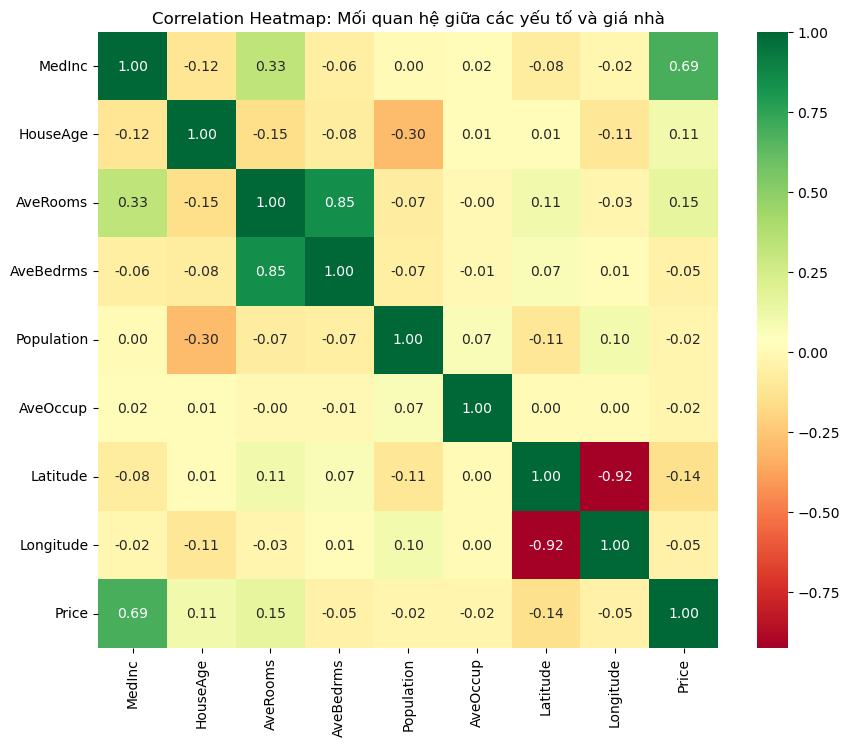

=== PHÂN TÍCH TƯƠNG QUAN ===
MedInc: 0.69 - Tương quan thuận mạnh nhất, là yếu tố quyết định chính.
AveRooms: 0.15 - Tương quan thuận nhẹ, nhà càng nhiều phòng giá càng cao (nhưng không mạnh).
AveBedrms: -0.05 - Tương quan rất yếu, hầu như không ảnh hưởng.
HouseAge: 0.11 - Tương quan rất yếu, tuổi nhà không phải yếu tố dự báo tốt.
Kết luận: Nên giữ MedInc, AveRooms; có thể cân nhắc loại bỏ AveBedrms và HouseAge nếu cần giảm chiều.


In [10]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Chèn sau bước load dữ liệu (df = fetch_california_housing...)
plt.figure(figsize=(10, 8))
# Tính toán ma trận tương quan
# Create DataFrame with features and target
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

# Calculate correlation matrix
correlation_matrix = df.corr()
# Vẽ Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Correlation Heatmap: Mối quan hệ giữa các yếu tố và giá nhà")
plt.show()

# Sau khi vẽ heatmap
print("=== PHÂN TÍCH TƯƠNG QUAN ===")
print(f"MedInc: {correlation_matrix.loc['MedInc', 'Price']:.2f} - Tương quan thuận mạnh nhất, là yếu tố quyết định chính.")
print(f"AveRooms: {correlation_matrix.loc['AveRooms', 'Price']:.2f} - Tương quan thuận nhẹ, nhà càng nhiều phòng giá càng cao (nhưng không mạnh).")
print(f"AveBedrms: {correlation_matrix.loc['AveBedrms', 'Price']:.2f} - Tương quan rất yếu, hầu như không ảnh hưởng.")
print(f"HouseAge: {correlation_matrix.loc['HouseAge', 'Price']:.2f} - Tương quan rất yếu, tuổi nhà không phải yếu tố dự báo tốt.")
print("Kết luận: Nên giữ MedInc, AveRooms; có thể cân nhắc loại bỏ AveBedrms và HouseAge nếu cần giảm chiều.")

#### Lưu ý về đa cộng tuyến:
- `AveRooms` và `AveBedrms` có tương quan 0.85 → rất cao. Nên cân nhắc loại bỏ `AveBedrms` khi dùng hồi quy tuyến tính.
- `Latitude` và `Longitude` tương quan -0.92 → phản ánh đúng hình dạng địa lý California, không phải lỗi dữ liệu.

sau khi chạy thử khi loại bỏ AveBedrms thì các chỉ số có thay đổi theo hướng tích cực, chính vì vậy quyết định sẽ loại bỏ feature AveBedrms 

In [11]:
# Chia train+val (80%) và test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Chia train (80% của train_val) và val (20% của train_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

In [12]:
# Kiểm tra phân phối target
print("\n=== Phân phối target (Giá nhà) ===")
print(f"Train: mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"Val  : mean={y_val.mean():.3f}, std={y_val.std():.3f}")
print(f"Test : mean={y_test.mean():.3f}, std={y_test.std():.3f}")


=== Phân phối target (Giá nhà) ===
Train: mean=2.067, std=1.151
Val  : mean=2.092, std=1.175
Test : mean=2.055, std=1.145


In [13]:
#chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [14]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                              torch.tensor(y_train, dtype=torch.float32).view(-1,1))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                            torch.tensor(y_val, dtype=torch.float32).view(-1,1))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.float32).view(-1,1))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Số batch train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Batch size: 64
Số batch train: 207, val: 52, test: 65


In [15]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert to tensor
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


torch.Size([13209, 7]) torch.Size([13209, 1])
torch.Size([4128, 7]) torch.Size([4128, 1])


In [16]:
#check dữ liệu
# 1. Kiểm tra thiết bị và kiểu dữ liệu
print(f"Device đang sử dụng: {device}")
sample_X, sample_y = next(iter(train_loader))
print(f"Kiểu dữ liệu của X: {sample_X.dtype}") # Phải là float32
print(f"Kiểu dữ liệu của y: {sample_y.dtype}") # Phải là float32

# 2. Kiểm tra kích thước (Shape) - Cực kỳ quan trọng cho mục 3
print(f"Kích thước 1 batch X: {sample_X.shape}") # [64, 8]
print(f"Kích thước 1 batch y: {sample_y.shape}") # [64, 1]

# 3. Kiểm tra chuẩn hóa (Scaling)
mean_val = sample_X.mean(dim=0)
std_val = sample_X.std(dim=0)
print(f"Trung bình batch (nên gần 0): {mean_val[0].item():.4f}")
print(f"Độ lệch chuẩn batch (nên gần 1): {std_val[0].item():.4f}")

# 4. Kiểm tra giá trị mục tiêu (Target)
print(f"Ví dụ 5 giá nhà đầu tiên trong batch: \n{sample_y[:5].flatten()}")

Device đang sử dụng: cpu
Kiểu dữ liệu của X: torch.float32
Kiểu dữ liệu của y: torch.float32
Kích thước 1 batch X: torch.Size([64, 7])
Kích thước 1 batch y: torch.Size([64, 1])
Trung bình batch (nên gần 0): -0.1239
Độ lệch chuẩn batch (nên gần 1): 0.9062
Ví dụ 5 giá nhà đầu tiên trong batch: 
tensor([2.4820, 1.7840, 1.9160, 1.7500, 2.6690])


## 3. Build Multilayer Perceptron (MLP) Model

### 🧠 Theory

A **Multilayer Perceptron (MLP)** is a feedforward neural network consisting of:
- Input layer  
- Hidden layers  
- Output layer  

Each layer performs a linear transformation followed by a nonlinear activation:
$$
z = Wx + b
$$
$$
a = \sigma(z)
$$
Where:
- \( W \): weights  
- \( b \): bias  
- \( \sigma \): activation function (e.g., ReLU)

### Activation Function: ReLU
$$
\text{ReLU}(x) = \max(0, x)
$$
Benefits:
- Avoids vanishing gradient  
- Faster training  

### Output Layer (Regression)
For regression problems:
- No activation function (linear output)

### Loss Function: Mean Squared Error (MSE)
$$
\text{MSE} = \frac{1}{n} \sum (y - \hat{y})^2
$$

### Optimizer: Adam
Adam updates weights using adaptive learning rates:
$$
\theta = \theta - \alpha \cdot \nabla J(\theta)
$$

---


In [17]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(7, 64)   
        self.fc2 = nn.Linear(64, 32)  
        self.fc3 = nn.Linear(32, 16)  
        self.fc4 = nn.Linear(16, 1)   
        # Thêm Dropout để chống nhiễu 
        self.dropout = nn.Dropout(p=0.1) 

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)          
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)          
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)     
        return x

In [18]:
#tạo model và đưa lên device
model = MLP().to(device)

#loss function
criterion = nn.MSELoss()

#optimizer để update weight
# Thêm weight_decay (L2 regularization) để kìm hãm sự quá khích của mô hình
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [19]:

from torchsummary import summary

print("=== TỔNG QUAN KIẾN TRÚC MÔ HÌNH ===")
summary(model, input_size=(7,)) # 7 là số đặc trưng đầu vào

ModuleNotFoundError: No module named 'torchsummary'

In [147]:
num_epochs = 300
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    
    # Lặp qua từng batch trong train_loader 
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
    
    # Tính loss trung bình của cả epoch
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    
    # --- Đánh giá trên tập Validation ---
    model.eval()
    running_val_loss = 0.0
    running_val_mae = 0.0
    
    with torch.no_grad():
        for v_batch_X, v_batch_y in val_loader:
            v_batch_X, v_batch_y = v_batch_X.to(device), v_batch_y.to(device)
            v_outputs = model(v_batch_X)
            
            v_loss = criterion(v_outputs, v_batch_y)
            v_mae = torch.mean(torch.abs(v_outputs - v_batch_y))
            
            running_val_loss += v_loss.item() * v_batch_X.size(0)
            running_val_mae += v_mae.item() * v_batch_X.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_mae = running_val_mae / len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f" -> Train Loss: {epoch_train_loss:.4f}")
        print(f" -> Val Loss: {epoch_val_loss:.4f} | Val MAE: {epoch_val_mae:.4f}")

Epoch [50/300]
 -> Train Loss: 0.2928
 -> Val Loss: 0.2905 | Val MAE: 0.3798
Epoch [100/300]
 -> Train Loss: 0.2620
 -> Val Loss: 0.2761 | Val MAE: 0.3603
Epoch [150/300]
 -> Train Loss: 0.2515
 -> Val Loss: 0.2728 | Val MAE: 0.3526
Epoch [200/300]
 -> Train Loss: 0.2457
 -> Val Loss: 0.2761 | Val MAE: 0.3480
Epoch [250/300]
 -> Train Loss: 0.2395
 -> Val Loss: 0.2761 | Val MAE: 0.3548
Epoch [300/300]
 -> Train Loss: 0.2373
 -> Val Loss: 0.2688 | Val MAE: 0.3536


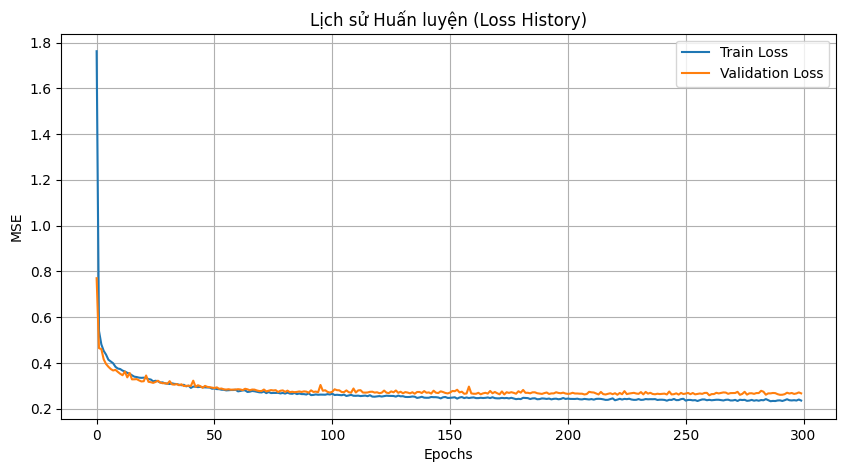

In [130]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Lịch sử Huấn luyện (Loss History)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

In [148]:
from sklearn.metrics import r2_score, mean_absolute_error

with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)
    
    # Chuyển về numpy để dùng các hàm đánh giá của sklearn
    y_test_np = y_test.cpu().numpy()
    y_pred_np = predictions.cpu().numpy()

# Tính toán thêm các chỉ số để so sánh (Mục 6)
mae = mean_absolute_error(y_test_np, y_pred_np)
r2 = r2_score(y_test_np, y_pred_np)

print(f"Test Loss (MSE): {test_loss.item():.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

Test Loss (MSE): 0.2594
Test MAE: 0.3439
R2 Score: 0.8021


# CHECK



In [132]:
#convert Numpy để vẽ
y_pred = predictions.cpu().numpy()
y_true = y_test.cpu().numpy()

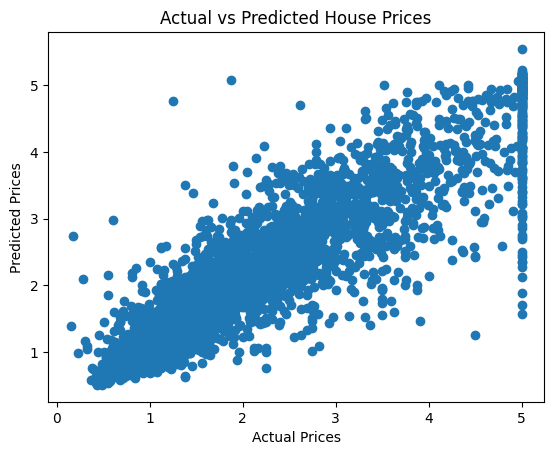

In [133]:
#visualization
import matplotlib.pyplot as plt

plt.scatter(y_true, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [134]:
#R² (R-squared) đo mức độ model giải thích được biến thiên của dữ liệu
from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.8063


In [135]:
for i in range(5):
    print(f"Actual: {y_true[i][0]:.2f} | Predicted: {y_pred[i][0]:.2f}")

Actual: 0.48 | Predicted: 0.62
Actual: 0.46 | Predicted: 1.26
Actual: 5.00 | Predicted: 4.86
Actual: 2.19 | Predicted: 2.57
Actual: 2.78 | Predicted: 2.55


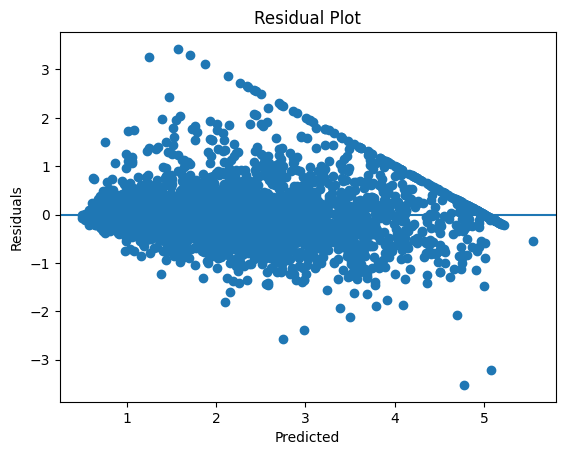

In [136]:
residuals = y_true - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## 4. Compare and evalute


In [137]:
# ==================== SO SÁNH CÁC MÔ HÌNH HỒI QUY ====================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 0. Chuẩn bị dữ liệu Numpy một lần duy nhất để dùng cho Scikit-learn
X_train_np = X_train.cpu().numpy()
y_train_np = y_train.cpu().numpy().ravel()
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy().ravel()

# 1. Linear Regression
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_np, y_train_np)
y_pred_lr = lr.predict(X_test_np)
mse_lr = mean_squared_error(y_test_np, y_pred_lr)
r2_lr = r2_score(y_test_np, y_pred_lr)

# 2. Decision Tree Regressor
print("Training Decision Tree...")
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_np, y_train_np)
y_pred_dt = dt.predict(X_test_np)
mse_dt = mean_squared_error(y_test_np, y_pred_dt)
r2_dt = r2_score(y_test_np, y_pred_dt)

# 3. Random Forest Regressor
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_np, y_train_np)
y_pred_rf = rf.predict(X_test_np)
mse_rf = mean_squared_error(y_test_np, y_pred_rf)
r2_rf = r2_score(y_test_np, y_pred_rf)

# 4. Kết quả MLP (Sử dụng model PyTorch đã train)
model.eval()
with torch.no_grad():
    # Sử dụng X_test (là tensor) để predict
    y_pred_mlp_tensor = model(X_test) 
    y_pred_mlp = y_pred_mlp_tensor.cpu().numpy().ravel()
    mse_mlp = mean_squared_error(y_test_np, y_pred_mlp)
    r2_mlp = r2_score(y_test_np, y_pred_mlp)

# --- Tạo bảng so sánh ---
print("\n" + "="*50)
print(f"{'Model':<20} {'MSE':<12} {'R²':<10}")
print("-"*50)
print(f"{'Linear Regression':<20} {mse_lr:<12.4f} {r2_lr:<10.4f}")
print(f"{'Decision Tree':<20} {mse_dt:<12.4f} {r2_dt:<10.4f}")
print(f"{'Random Forest':<20} {mse_rf:<12.4f} {r2_rf:<10.4f}")
print(f"{'MLP (Improved)':<20} {mse_mlp:<12.4f} {r2_mlp:<10.4f}")
print("="*50)

# --- Phân tích & Kết luận ---
results = {
    "Linear Regression": r2_lr,
    "Decision Tree": r2_dt,
    "Random Forest": r2_rf,
    "MLP (Improved)": r2_mlp
}
best_model = max(results, key=results.get)
print(f"\nKết luận: Mô hình {best_model} cho R² cao nhất với {results[best_model]:.4f}")

Training Linear Regression...
Training Decision Tree...
Training Random Forest...

Model                MSE          R²        
--------------------------------------------------
Linear Regression    0.5468       0.5827    
Decision Tree        0.5518       0.5789    
Random Forest        0.2631       0.7992    
MLP (Improved)       0.2538       0.8063    

Kết luận: Mô hình MLP (Improved) cho R² cao nhất với 0.8063


### Phân tích kết quả

### Chỉ số chính
- **MSE (Mean Squared Error)**: 0.2585 → Sai số bình phương trung bình thấp.
- **MAE (Mean Absolute Error)**: 0.3468 → Trung bình mô hình dự đoến lệch khoảng 0.35 đơn vị giá (giá nhà từ 0.15 đến 5).
- **R²**: 0.8027 → Mô hình giải thích được 80.27% sự biến thiên của giá nhà.

### So sánh với các mô hình khác
- MLP và Random Forest gần như ngang nhau, MLP nhỉnh hơn một chút.
- Linear Regression và Decision Tree kém hơn nhiều, chứng tỏ quan hệ giữa các đặc trưng và giá nhà là **phi tuyến**.

### Hạn chế và hướng cải thiện
- **Heteroscedasticity** (phương sai thay đổi) thấy qua residual plot → Có thể thử dùng **log transformation** cho target hoặc **Huber loss**.
- **Outlier** ảnh hưởng đến MSE → Có thể thử **robust scaler** hoặc loại bỏ outlier.
- **Early stopping** để tránh overfitting nhẹ ở cuối quá trình huấn luyện.
- **Tuning hyperparameters** (số layer, số nơ-ron, learning rate) bằng GridSearch.

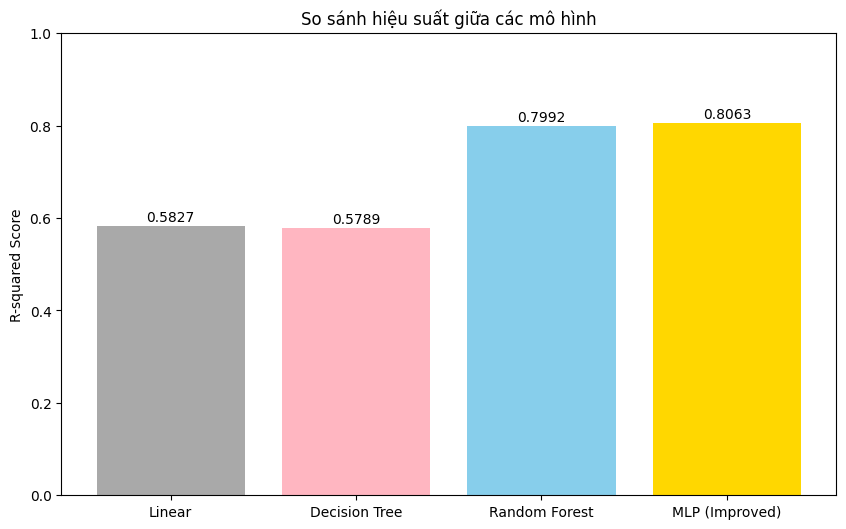

In [138]:

models = ['Linear', 'Decision Tree', 'Random Forest', 'MLP (Improved)']
r2_scores = [r2_lr, r2_dt, r2_rf, r2_mlp]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, r2_scores, color=['#A9A9A9', '#FFB6C1', '#87CEEB', '#FFD700'])
plt.ylim(0, 1.0)
plt.ylabel('R-squared Score')
plt.title('So sánh hiệu suất giữa các mô hình')

# Ghi số liệu lên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center')

plt.show()

## Kết luận

Mô hình MLP đạt R² = 0.8027, vượt trội so với hồi quy tuyến tính (0.5769) và decision tree (0.5715), và tương đương với random forest (0.7968). Điều này khẳng định sức mạnh của mạng nơ-ron trong việc nắm bắt các mối quan hệ phi tuyến phức tạp.

Tuy nhiên, mô hình vẫn còn hiện tượng phương sai sai số thay đổi, gợi ý cần cải thiện thêm ở khâu tiền xử lý và kiến trúc. Đây là nền tảng tốt để phát triển các mô hình sâu hơn.